# Тихонов Илья

## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              344 non-null    object 
 1   Island               344 non-null    object 
 2   Clutch Completion    344 non-null    object 
 3   Date Egg             344 non-null    int64  
 4   Culmen Length (mm)   342 non-null    float64
 5   Culmen Depth (mm)    342 non-null    float64
 6   Flipper Length (mm)  342 non-null    float64
 7   Body Mass (g)        342 non-null    float64
 8   Sex                  334 non-null    object 
 9   Delta 15 N (o/oo)    330 non-null    float64
 10  Delta 13 C (o/oo)    331 non-null    float64
dtypes: float64(6), int64(1), object(4)
memory usage: 29.7+ KB


In [4]:
data.isna().sum()


Species                 0
Island                  0
Clutch Completion       0
Date Egg                0
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     2
Body Mass (g)           2
Sex                    10
Delta 15 N (o/oo)      14
Delta 13 C (o/oo)      13
dtype: int64

В датасете содержаться пропуски

In [5]:
data = data.dropna()
data.isna().sum()

Species                0
Island                 0
Clutch Completion      0
Date Egg               0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
Delta 15 N (o/oo)      0
Delta 13 C (o/oo)      0
dtype: int64

In [6]:
data[['Species', 'Island', 'Sex' ]].nunique()

Species    3
Island     3
Sex        3
dtype: int64

In [7]:
data['Sex'].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

In [8]:
data[data['Sex'] == '.']

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
41,Gentoo,Biscoe,Yes,0,44.5,15.7,217.0,4875.0,.,8.04111,-26.18444


В признаке `Sex` оказался пропуск в виде точки, поэтому удалю этот объект

In [9]:
data = data[data['Sex'] != '.'].reset_index(drop=True)
data.nunique()

Species                  3
Island                   3
Clutch Completion        2
Date Egg                50
Culmen Length (mm)     159
Culmen Depth (mm)       79
Flipper Length (mm)     53
Body Mass (g)           93
Sex                      2
Delta 15 N (o/oo)      324
Delta 13 C (o/oo)      324
dtype: int64

Сейчас закодирую категориальные признаки. `Sex`, `Island` и `Clutch Completion` закодирую через OneHot, чтобы не вводить искусственный порядок на данных.

In [10]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
data_cat = data[['Island', 'Sex', 'Clutch Completion']]
data_cat_encoded = encoder.fit_transform(data_cat)
data_cat_encoded = pd.DataFrame(data_cat_encoded, columns=encoder.get_feature_names_out(), index=data.index)

data = pd.concat([data.drop(['Island', 'Sex', 'Clutch Completion'], axis=1), data_cat_encoded], axis=1)
data.head()


,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Biscoe,Island_Dream,Island_Torgersen,Sex_FEMALE,Sex_MALE,Clutch Completion_No,Clutch Completion_Yes
0,Chinstrap,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,Chinstrap,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,Gentoo,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,Chinstrap,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,Gentoo,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,1.0,0.0,0.0,1.0,0.0,0.0,1.0


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [11]:
data['Species'].unique()

array(['Chinstrap', 'Gentoo', 'Adelie'], dtype=object)

In [12]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['Chinstrap', 'Gentoo', 'Adelie']])
data['Species'] = encoder.fit_transform(data[['Species']]).astype(int)
data.head()

,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Biscoe,Island_Dream,Island_Torgersen,Sex_FEMALE,Sex_MALE,Clutch Completion_No,Clutch Completion_Yes
0,0,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,0,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,1,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,1,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,1.0,0.0,0.0,1.0,0.0,0.0,1.0


**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [13]:
from sklearn.model_selection import train_test_split

np.random.seed(2352353)

X = data.drop('Species', axis=1)
y = data['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2352353, stratify=y)


`stratify` используем чтобы сохранить пропорции целевой перменной и в тестовой и в тренировочной выборках

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

Сначала проведем масштабирование

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train[['Flipper Length (mm)', 'Body Mass (g)']])
X_train_scaled = scaler.transform(X_train[['Flipper Length (mm)', 'Body Mass (g)']])
X_test_scaled = scaler.transform(X_test[['Flipper Length (mm)', 'Body Mass (g)']])


In [15]:
from sklearn.neighbors import KNeighborsClassifier

cnt_neighbors = [1, 3, 5, 10, 15, 25]

models = []

for neighbors in cnt_neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbors, p=2, n_jobs=8)
    knn.fit(X_train_scaled, y_train)

    models.append(knn)

    train_score = knn.score(X_train_scaled, y_train)
    test_score = knn.score(X_test_scaled, y_test)
    print(neighbors, train_score, test_score)

1 0.9646017699115044 0.7857142857142857
3 0.8805309734513275 0.7857142857142857
5 0.8495575221238938 0.7959183673469388
10 0.831858407079646 0.8163265306122449
15 0.8362831858407079 0.8061224489795918
25 0.831858407079646 0.8163265306122449


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [16]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [17]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

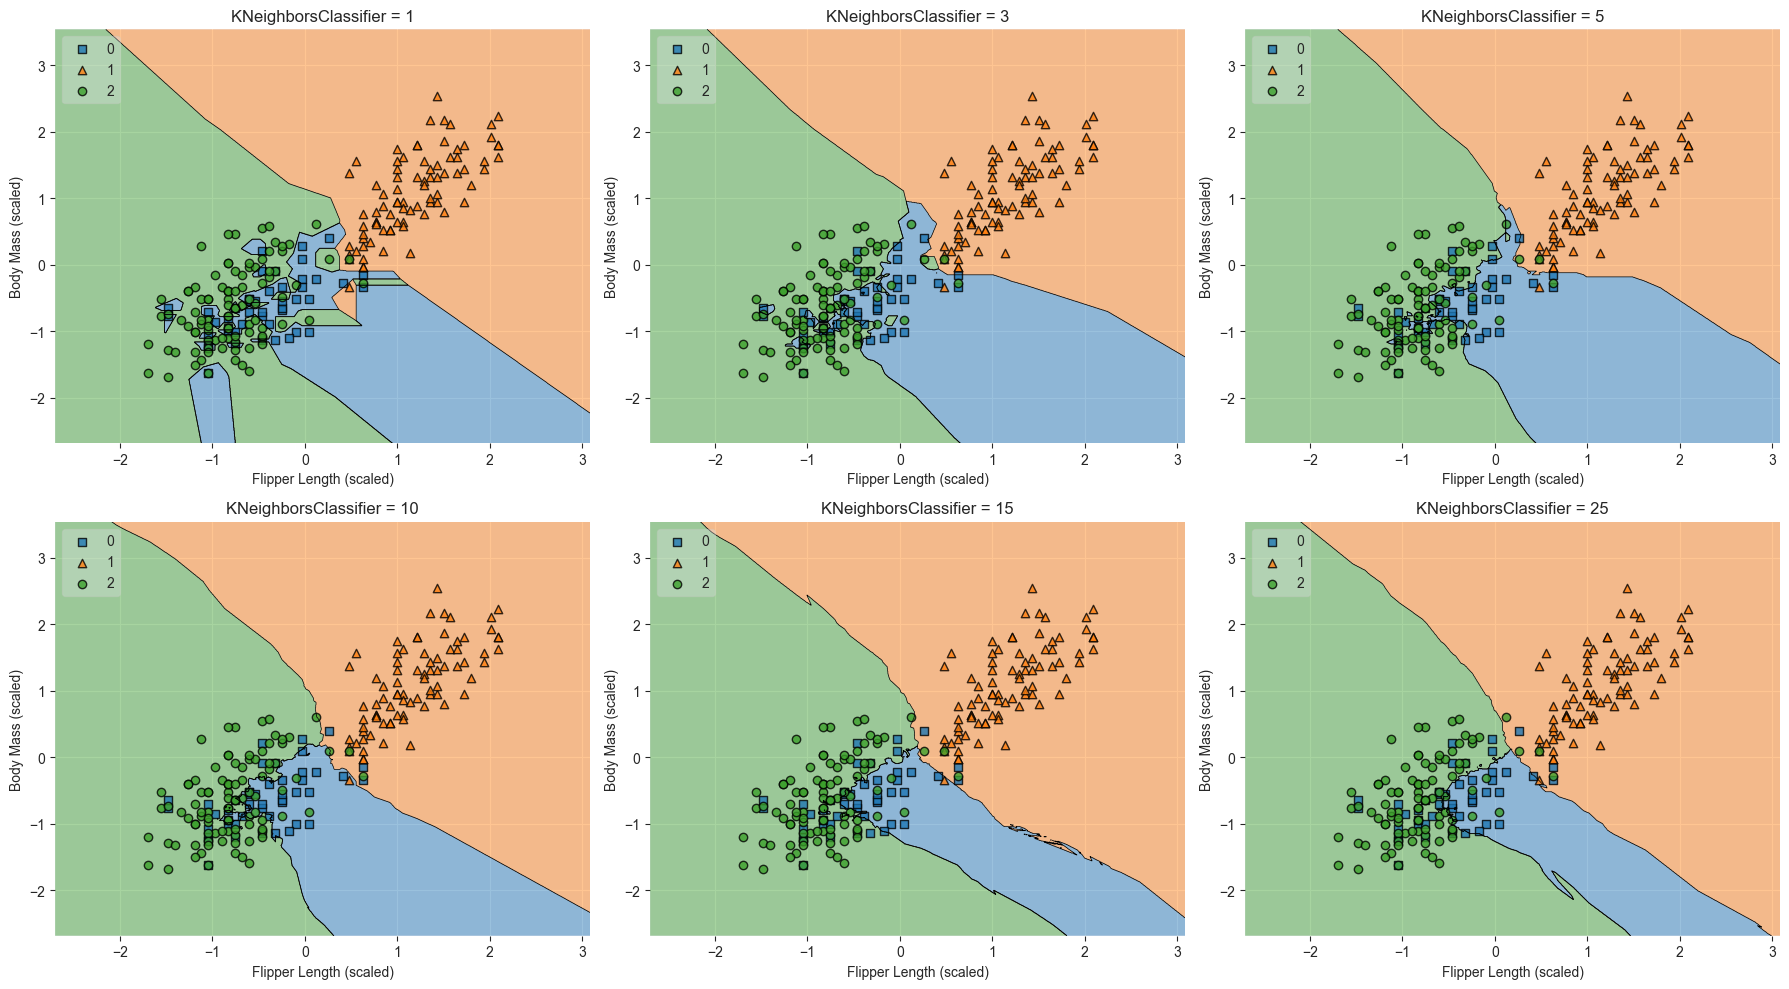

In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools
from mlxtend.plotting import plot_decision_regions

X_plot = X_train_scaled
y_plot = np.array(y_train)

labels = [
    'KNeighborsClassifier = 1',
    'KNeighborsClassifier = 3',
    'KNeighborsClassifier = 5',
    'KNeighborsClassifier = 10',
    'KNeighborsClassifier = 15',
    'KNeighborsClassifier = 25'
]

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3)

for clf, lab, grd in zip(models, labels, itertools.product([0, 1], [0, 1, 2])):
    ax = plt.subplot(gs[grd[0], grd[1]])
    plot_decision_regions(X=X_plot, y=y_plot, clf=clf, legend=2, ax=ax)
    ax.set_title(lab)
    ax.set_xlabel('Flipper Length (scaled)')
    ax.set_ylabel('Body Mass (scaled)')

plt.tight_layout()
plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

Явное переобучение видно при `k=1, 3` - очень большая разница между тестовой и обучающей выборки

`k=25` дает лучшие значения, на тестовой выборке, поэтому я бы выбрал его


**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

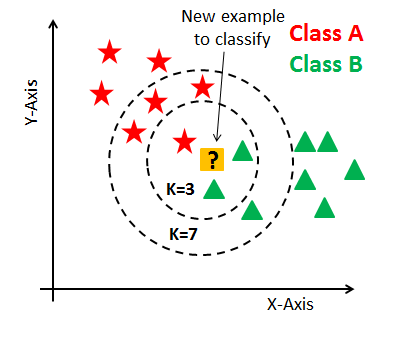

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [19]:
import numpy as np
from collections import Counter

# буду использовать евклидову метрику
class KNN:
    def __init__(self, k:int):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y)

    def predict(self, X):
        X = np.asarray(X, dtype=float)

        distances = self.count_distance(X[:, np.newaxis, :], self.X_train[np.newaxis, :, :])

        nearest_indices = np.argsort(distances, axis=1)[:, :self.k]

        nearest_labels = self.y_train[nearest_indices]

        predictions = []
        for labels in nearest_labels:
            counts = Counter(labels)
            max_count = max(counts.values())

            candidates = {label for label, cnt in counts.items() if cnt == max_count}
            for label in labels:
                if label in candidates:
                    predictions.append(label)
                    break

        return np.array(predictions)

    def count_distance(self, x, y):
        return np.linalg.norm(x - y, axis=-1)

In [20]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [21]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [22]:
best_k = None
best_score = -1

for neighbors in cnt_neighbors:
    knn = KNN(k=neighbors)

    knn.fit(X_train_scaled, y_train)
    predictions = knn.predict(X_test_scaled)
    score = np.mean(predictions == y_test)

    print(neighbors, score)

    if score > best_score:
        best_score = score
        best_k = neighbors

print(f'best_k={best_k}, best_score={best_score:.6f}')


1 0.7857142857142857
3 0.7857142857142857
5 0.7959183673469388
10 0.8061224489795918
15 0.8061224489795918
25 0.8163265306122449
best_k=25, best_score=0.816327


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [23]:
data = pd.read_csv('diamonds.csv')
data = data.sample(frac=1, random_state=43524).reset_index(drop=True)
print(data.shape)
data.head(5)

(53940, 11)


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,29983,0.43,Ideal,I,VS2,62.0,55.0,716,4.84,4.87,3.01
1,36407,0.31,Premium,E,VS1,61.7,58.0,942,4.36,4.30,2.67
2,20612,1.53,Premium,I,SI1,61.5,59.0,8911,7.39,7.32,4.52
3,49275,0.54,Ideal,G,VVS2,60.6,56.0,2090,5.27,5.26,3.19
4,24039,0.38,Premium,I,VS2,61.7,59.0,633,4.60,4.64,2.85


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [24]:
data.isna().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

пропущенных значений нет, а столбец `Unnamed: 0` является бессмысленным, так как он просто нумерует строки

In [25]:
data.duplicated().sum()

np.int64(0)

In [26]:
data.drop(columns=['Unnamed: 0'], inplace=True)
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.43,Ideal,I,VS2,62.0,55.0,716,4.84,4.87,3.01
1,0.31,Premium,E,VS1,61.7,58.0,942,4.36,4.30,2.67
2,1.53,Premium,I,SI1,61.5,59.0,8911,7.39,7.32,4.52
3,0.54,Ideal,G,VVS2,60.6,56.0,2090,5.27,5.26,3.19
4,0.38,Premium,I,VS2,61.7,59.0,633,4.60,4.64,2.85


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

<Axes: >

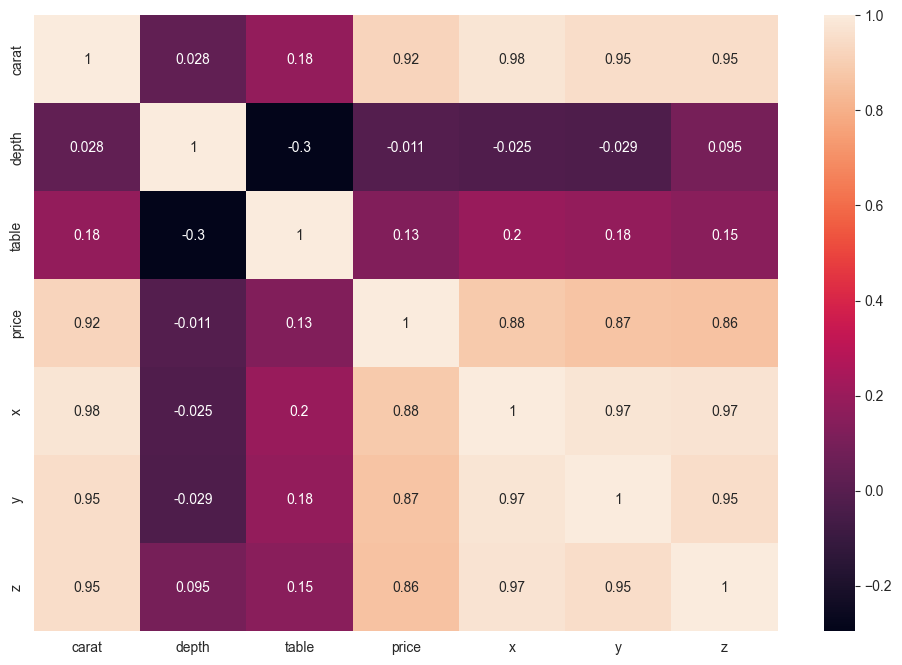

In [27]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(data.select_dtypes(include=[np.number]).corr(), annot=True, ax=ax)

С целевой переменной `price` наиболее сильно коррелируют признаки `carat`, `x`, `y` и `z`, а наименее  `depth` и `table`

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [28]:
cat_cols = data.select_dtypes(include='object').columns
cat_cols


Index(['cut', 'color', 'clarity'], dtype='object')

**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [29]:
train, test = train_test_split(data, test_size=0.3, random_state=345345)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [30]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

cat_cols = train.select_dtypes(include='object').columns
num_cols = train.select_dtypes(exclude='object').drop(columns=['price']).columns

X_train_cat = pd.DataFrame(
    encoder.fit_transform(train[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=train.index
)
X_test_cat = pd.DataFrame(
    encoder.transform(test[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=test.index
)

X_train_raw = pd.concat([train[num_cols], X_train_cat], axis=1)
X_test_raw = pd.concat([test[num_cols], X_test_cat], axis=1)

y_train = train['price'].values
y_test = test['price'].values
feature_names = X_train_raw.columns


In [31]:
scaler = StandardScaler()

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

X_train[num_cols] = scaler.fit_transform(X_train_raw[num_cols])
X_test[num_cols] = scaler.transform(X_test_raw[num_cols])


После стандартизации вещественных признаков коэффициенты показывают вклад признаков в сопоставимом масштабе (изменение `y` при изменении признака на 1 стандартное отклонение), поэтому их удобнее сравнивать между собой. Но интерпретация в исходных единицах (например, `+1 мм`) теряется.

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print('Train MSE:', mean_squared_error(y_train, y_train_pred))
print('Test MSE:', mean_squared_error(y_test, y_test_pred))

print('Train RMSE:', np.sqrt(mean_squared_error(y_train, y_train_pred)))
print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))


Train MSE: 1295918.969385053
Test MSE: 1233663.378483282
Train RMSE: 1138.384368034388
Test RMSE: 1110.7040012907498


MSE на тестовой выборке немного меньше, чем на тренировочной, поэтому явных признаков сильного переобучения на этом split не видно. Для более надежного вывода лучше дополнительно смотреть кросс-валидацию.

**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [33]:
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': model.coef_
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print('intercept_ =', model.intercept_)
coef_df


intercept_ = 3375.6847700722865


,feature,coef,abs_coef
0,carat,5237.386085,5237.386085
18,clarity_I1,-3829.878851,3829.878851
19,clarity_IF,1575.481033,1575.481033
17,color_J,-1545.358008,1545.358008
24,clarity_VVS1,1202.169050,1202.169050
25,clarity_VVS2,1138.112684,1138.112684
21,clarity_SI2,-1116.417459,1116.417459
3,x,-1002.732189,1002.732189
11,color_D,832.964804,832.964804
22,clarity_VS1,748.510208,748.510208


Среди вещественных переменных наибольшие по модулю коэффициенты имеют признаки `carat` и `x`

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [34]:
 from sklearn.linear_model import Lasso, Ridge

alpha = 10

lasso = Lasso(alpha=alpha)
lasso.fit(X_train, y_train)
y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

ridge = Ridge(alpha=alpha)
ridge.fit(X_train, y_train)
y_train_pred_ridge = ridge.predict(X_train)
y_test_pred_ridge = ridge.predict(X_test)

print('Lasso Train MSE:', mean_squared_error(y_train, y_train_pred))
print('Lasso Test MSE:', mean_squared_error(y_test, y_test_pred))

print('Ridge Train MSE:', mean_squared_error(y_train, y_train_pred_ridge))
print('Ridge Test MSE:', mean_squared_error(y_test, y_test_pred_ridge))

Lasso Train MSE: 1332379.2463032263
Lasso Test MSE: 1277998.9824883842
Ridge Train MSE: 1296075.918265149
Ridge Test MSE: 1234786.441156937


`MSE` после добавления регуляризации изменился: у Lasso с `alpha=10` ошибка выросла заметнее, у Ridge — слабее. Посмотрим на коэффициенты.

In [35]:
lasso_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': lasso.coef_
})
lasso_coef_df['abs_coef'] = lasso_coef_df['coef'].abs()
lasso_coef_df = lasso_coef_df.sort_values('abs_coef', ascending=False)

print('intercept_ =', lasso.intercept_)
print(sum(lasso_coef_df['abs_coef']))

lasso_coef_df


intercept_ = 4389.401570378397
17431.80878240892


,feature,coef,abs_coef
0,carat,4778.055441,4778.055441
18,clarity_I1,-3597.301213,3597.301213
17,color_J,-1649.728688,1649.728688
21,clarity_SI2,-1535.880439,1535.880439
16,color_I,-851.265485,851.265485
19,clarity_IF,739.972717,739.972717
20,clarity_SI1,-641.064212,641.064212
3,x,-601.648178,601.648178
24,clarity_VVS1,526.469371,526.469371
25,clarity_VVS2,513.270758,513.270758


In [36]:
ridge_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': ridge.coef_
})
ridge_coef_df['abs_coef'] = ridge_coef_df['coef'].abs()
ridge_coef_df = ridge_coef_df.sort_values('abs_coef', ascending=False)

print('intercept_ =', ridge.intercept_)
print(sum(ridge_coef_df['abs_coef']))
ridge_coef_df


intercept_ = 3383.71053243803
22286.342947426867


,feature,coef,abs_coef
0,carat,5200.331973,5200.331973
18,clarity_I1,-3758.420157,3758.420157
19,clarity_IF,1555.915870,1555.915870
17,color_J,-1534.718254,1534.718254
24,clarity_VVS1,1190.320500,1190.320500
25,clarity_VVS2,1127.462876,1127.462876
21,clarity_SI2,-1120.039261,1120.039261
3,x,-955.381308,955.381308
11,color_D,828.207982,828.207982
22,clarity_VS1,738.675472,738.675472


In [37]:
print(sum(coef_df['abs_coef']))
coef_df

22502.694752004714


,feature,coef,abs_coef
0,carat,5237.386085,5237.386085
18,clarity_I1,-3829.878851,3829.878851
19,clarity_IF,1575.481033,1575.481033
17,color_J,-1545.358008,1545.358008
24,clarity_VVS1,1202.169050,1202.169050
25,clarity_VVS2,1138.112684,1138.112684
21,clarity_SI2,-1116.417459,1116.417459
3,x,-1002.732189,1002.732189
11,color_D,832.964804,832.964804
22,clarity_VS1,748.510208,748.510208


L1-регуляризация при `alpha=10` занулила коэффициенты `y`, `cut_Premium`, `cut_Very Good`, `color_G`, что указывает на избыточность части признаков.
L2-регуляризация в основном сгладила веса без жесткого зануления.

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

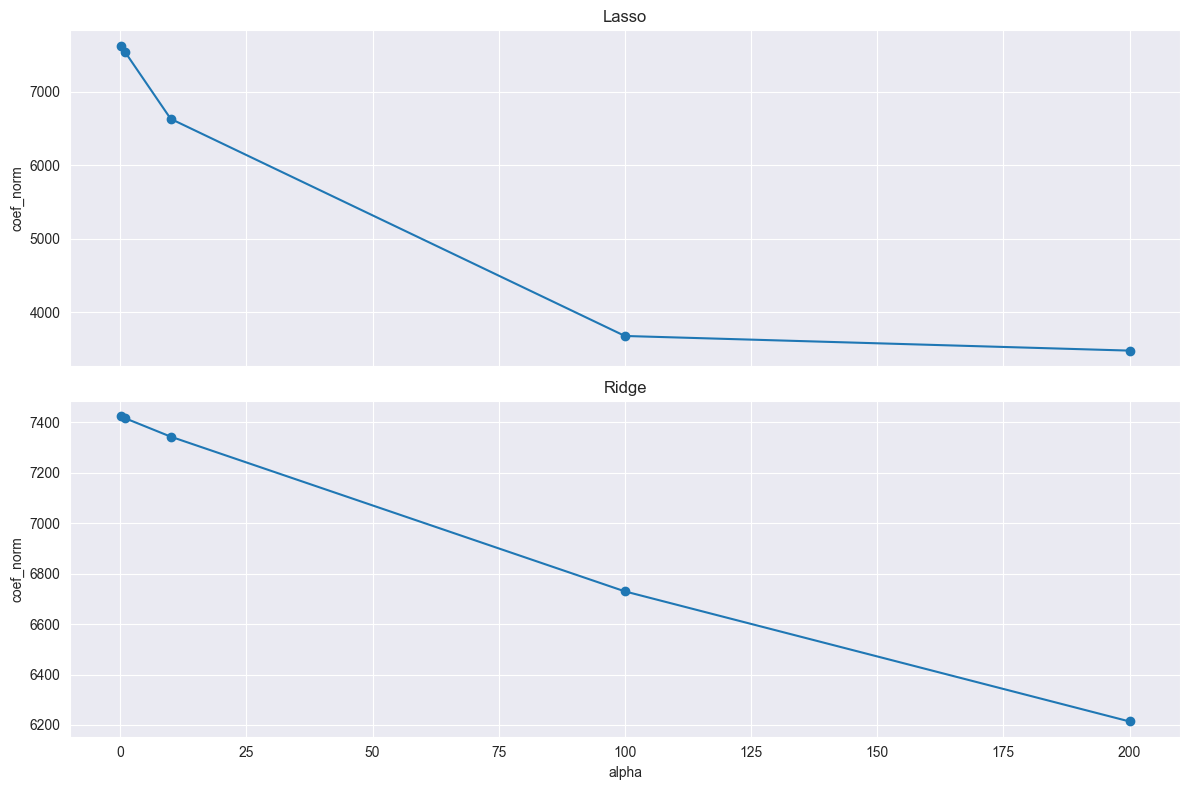

In [38]:
alphas = [0.1, 1, 10, 100, 200]
ridge_coef_norms = []
lasso_coef_norms = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_coef_norms.append(np.linalg.norm(lasso.coef_))

    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_coef_norms.append(np.linalg.norm(ridge.coef_))

fig, ax = plt.subplots(nrows=2, figsize=(12, 8), sharex=True)

ax[0].plot(alphas, lasso_coef_norms, marker='o')
ax[0].set_title('Lasso')
ax[0].set_ylabel('coef_norm')

ax[1].plot(alphas, ridge_coef_norms, marker='o')
ax[1].set_title('Ridge')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('coef_norm')

plt.tight_layout()
plt.show()

Lasso-регрессия сильнее снижает норму коэффициентов, так как она может занулять некоторые из них, в то время как Ridge-регрессия просто их уменьшает. Lasso-регрессию часто используют для отбора признаков, так как она может полностью исключить неинформативные признаки, зануляя их коэффициенты, что делает модель более интерпретируемой и может улучшить её обобщающую способность.

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [39]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

LassoCV(alphas=[0.1, 1, 10, 100, 200], cv=5, max_iter=10000)

In [40]:
df_lasso = pd.DataFrame(lasso_cv.mse_path_, index=lasso_cv.alphas_).astype(np.float64)
df_lasso

,0,1,2,3,4
200.0,2.464740e+06,2.519450e+06,2.573697e+06,2.291326e+06,2.434138e+06
100.0,2.265488e+06,2.309631e+06,2.374274e+06,2.089688e+06,2.208215e+06
10.0,1.354172e+06,1.381709e+06,1.442783e+06,1.226749e+06,1.268851e+06
1.0,1.327924e+06,1.343064e+06,1.402134e+06,1.196193e+06,1.229006e+06
0.1,1.328497e+06,1.346129e+06,1.401582e+06,1.196317e+06,1.228267e+06


In [41]:
mean_mse = df_lasso.mean(axis=1)
mean_mse

200.0    2.456670e+06
100.0    2.249459e+06
10.0     1.334853e+06
1.0      1.299664e+06
0.1      1.300158e+06
dtype: float64

In [42]:
best_alpha = mean_mse.idxmin()
best_alpha


np.float64(1.0)

Лучшее качество достигается при $\alpha = 1.0$

**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [43]:
lasso = Lasso(alpha=best_alpha, max_iter=10000)
lasso.fit(X_train, y_train)

lasso_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': lasso.coef_
})
lasso_coef_df['abs_coef'] = lasso_coef_df['coef'].abs()
lasso_coef_df = lasso_coef_df.sort_values('abs_coef', ascending=False)

print('intercept_ =', lasso.intercept_)
print(sum(lasso_coef_df['abs_coef']))

lasso_coef_df


intercept_ = 4401.5254687194765
20728.121433888973


,feature,coef,abs_coef
0,carat,5192.637702,5192.637702
18,clarity_I1,-4294.530582,4294.530582
17,color_J,-1859.051462,1859.051462
21,clarity_SI2,-1646.105520,1646.105520
19,clarity_IF,1004.124751,1004.124751
16,color_I,-964.210891,964.210891
3,x,-958.818392,958.818392
20,clarity_SI1,-700.202231,700.202231
6,cut_Fair,-675.304824,675.304824
24,clarity_VVS1,646.698484,646.698484


Наиболее информативными по модулю коэффициентов оказались `carat`, `x`, а также несколько категориальных признаков чистоты/цвета (например, `clarity_I1`, `clarity_SI2`, `color_J`).
Неинформативными (коэффициент около нуля) оказались `y`, `cut_Very Good`, `color_G`.
Это логично: часть признаков размеров алмаза сильно коррелирует между собой (`x`, `y`, `z`, `carat`), а Lasso в условиях коррелированности оставляет более полезные признаки и зануляет избыточные.

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [44]:
lasso.fit(X_train, y_train)

y_test_pred = lasso.predict(X_test)

print('Lasso Test MSE:', mean_squared_error(y_test, y_test_pred))


Lasso Test MSE: 1234831.417959834


`Test MSE: 1233663.378483282`\

На тестовой выборке Lasso-регрессия показала среднеквадратичную ошибку 1234831.42, а обычная линейная регрессия - 1233663.38. Следовательно, немного лучше для предсказаний оказалась обычная линейная регрессия, так как её ошибка меньше.
Разница между моделями относительно небольшая, поэтому качество у них близкое.